# 2. Análisis unidimensional

Sección 9.10.4.1.2 del enunciado. Se analiza cada variable candidata por separado: las numéricas
con estadísticos de posición y dispersión, valores atípicos, forma de la distribución y faltantes;
las categóricas con sus frecuencias, categorías raras y posibles redundancias; y, al final, la
variable objetivo. Todos los estadísticos se calculan sobre los 1.348.059 préstamos cerrados, sin
muestreo. La única excepción es la prueba de Shapiro-Wilk, que solo es válida hasta
n = 5.000 y se aplica a una muestra aleatoria de ese tamaño.

In [1]:
import sys
import warnings

sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

import utils as u

u.estilo()
pd.set_option("display.max_columns", 30, "display.width", 180, "display.max_rows", 120)
df = u.cargar_prestamos(u.NUM_EDA + u.CAT_EDA + ["default", "issue_year"])
print(f"{len(df):,} préstamos x {df.shape[1]} columnas")

1,348,059 préstamos x 37 columnas


## 2.1 Variables numéricas

Se analizan 28 variables numéricas conocidas al originar el préstamo: monto, cuota, tasa de
interés, ingreso anual, razón deuda/ingreso (`dti`), puntaje FICO, antigüedad laboral y
crediticia, y el historial de cuentas, saldos, utilización y consultas del buró de crédito.

### 2.1.1 Estadísticos descriptivos, IQR y valores atípicos

Se consideran atípicos los valores fuera de $[Q_1 - 1{,}5\,IQR,\; Q_3 + 1{,}5\,IQR]$.

In [2]:
def resumen_numerico(s: pd.Series) -> dict:
    x = s.dropna()
    q1, q2, q3 = x.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    fuera = ((x < li) | (x > ls)).sum()
    return {"media": x.mean(), "mediana": q2, "desv_est": x.std(), "min": x.min(), "p25": q1,
            "p50": q2, "p75": q3, "max": x.max(), "IQR": iqr, "lim_inf": li, "lim_sup": ls,
            "n_atipicos": int(fuera), "%_atipicos": 100 * fuera / len(x),
            "asimetria": stats.skew(x), "curtosis": stats.kurtosis(x),
            "%_faltantes": 100 * s.isna().mean()}


num = pd.DataFrame({c: resumen_numerico(df[c]) for c in u.NUM_EDA}).T
num.round(2)

,media,mediana,desv_est,min,p25,p50,p75,max,IQR,lim_inf,lim_sup,n_atipicos,%_atipicos,asimetria,curtosis,%_faltantes
loan_amnt,14409.00,12000.00,8716.09,500.00,7975.00,12000.00,20000.00,40000.00,12025.00,-10062.50,38037.50,7154.0,0.53,0.78,-0.08,0.00
installment,437.78,375.04,261.50,4.93,248.28,375.04,580.22,1719.83,331.94,-249.62,1078.12,42189.0,3.13,1.01,0.75,0.00
int_rate,13.24,12.74,4.77,5.31,9.75,12.74,15.99,30.99,6.24,0.39,25.35,24977.0,1.85,0.71,0.51,0.00
annual_inc,76237.80,65000.00,69922.99,0.00,45750.06,65000.00,90000.00,10999200.00,44249.94,-20624.85,156374.91,66029.0,4.90,46.24,4803.39,0.00
dti,18.27,17.61,11.16,-1.00,11.79,17.61,24.05,999.00,12.26,-6.60,42.44,5484.0,0.41,27.09,2112.18,0.03
fico_range_low,696.16,690.00,31.85,610.00,670.00,690.00,710.00,845.00,40.00,610.00,770.00,46516.0,3.45,1.28,1.66,0.00
fico_range_high,700.16,694.00,31.85,614.00,674.00,694.00,714.00,850.00,40.00,614.00,774.00,46516.0,3.45,1.28,1.66,0.00
emp_length,5.96,6.00,3.69,0.00,2.00,6.00,10.00,10.00,8.00,-10.00,22.00,0.0,0.00,-0.22,-1.50,5.83
term,41.78,36.00,10.26,36.00,36.00,36.00,36.00,60.00,0.00,36.00,36.00,324878.0,24.10,1.21,-0.53,0.00
delinq_2yrs,0.32,0.00,0.88,0.00,0.00,0.00,0.00,39.00,0.00,0.00,0.00,259666.0,19.26,5.60,58.71,0.00


**Lectura de la tabla.**

* **Colas largas y atípicos genuinos.** `annual_inc`, `revol_bal`, `tot_cur_bal`,
  `total_rev_hi_lim` y `avg_cur_bal` tienen asimetrías entre 2,9 y 52 y curtosis entre 27 y casi
  13.000. Sus atípicos por IQR (entre 3,5 % y 6 %) son en su mayoría prestatarios de ingresos o
  saldos altos, no errores: eliminarlos sesgaría la población. Conviene una transformación
  logarítmica.
* **Conteos con masa en cero.** `delinq_2yrs`, `pub_rec` y `pub_rec_bankruptcies` tienen
  $Q_1 = Q_3 = 0$, así que el criterio del IQR marca como atípico cualquier valor positivo (entre
  12 % y 19 % de los préstamos). En estas variables el IQR no es un buen criterio: un préstamo con
  una mora previa no es un dato anómalo. Lo mismo ocurre con `term`, que solo toma dos valores.
* **Valores inválidos.** `dti` tiene dos valores negativos (−1) y 533 mayores que 100, 38 de ellos
  iguales a 999, un código de "sin dato". Se tratan como faltantes los valores de `dti` fuera de
  $[0, 100]$. `revol_util` (4.714 casos) y `bc_util` (21.261) superan el 100 %: son sobregiros
  reales de la línea de crédito y se conservan.
* **Variables casi simétricas.** `loan_amnt`, `int_rate`, `installment`, `open_acc` y `total_acc`
  tienen asimetría moderada (< 1,5) y pocos atípicos.

### 2.1.2 Histogramas

Para que la forma de la distribución sea visible, el eje horizontal se recorta en el percentil
99,5. El recorte afecta solo al gráfico; la tabla anterior usa todos los datos.

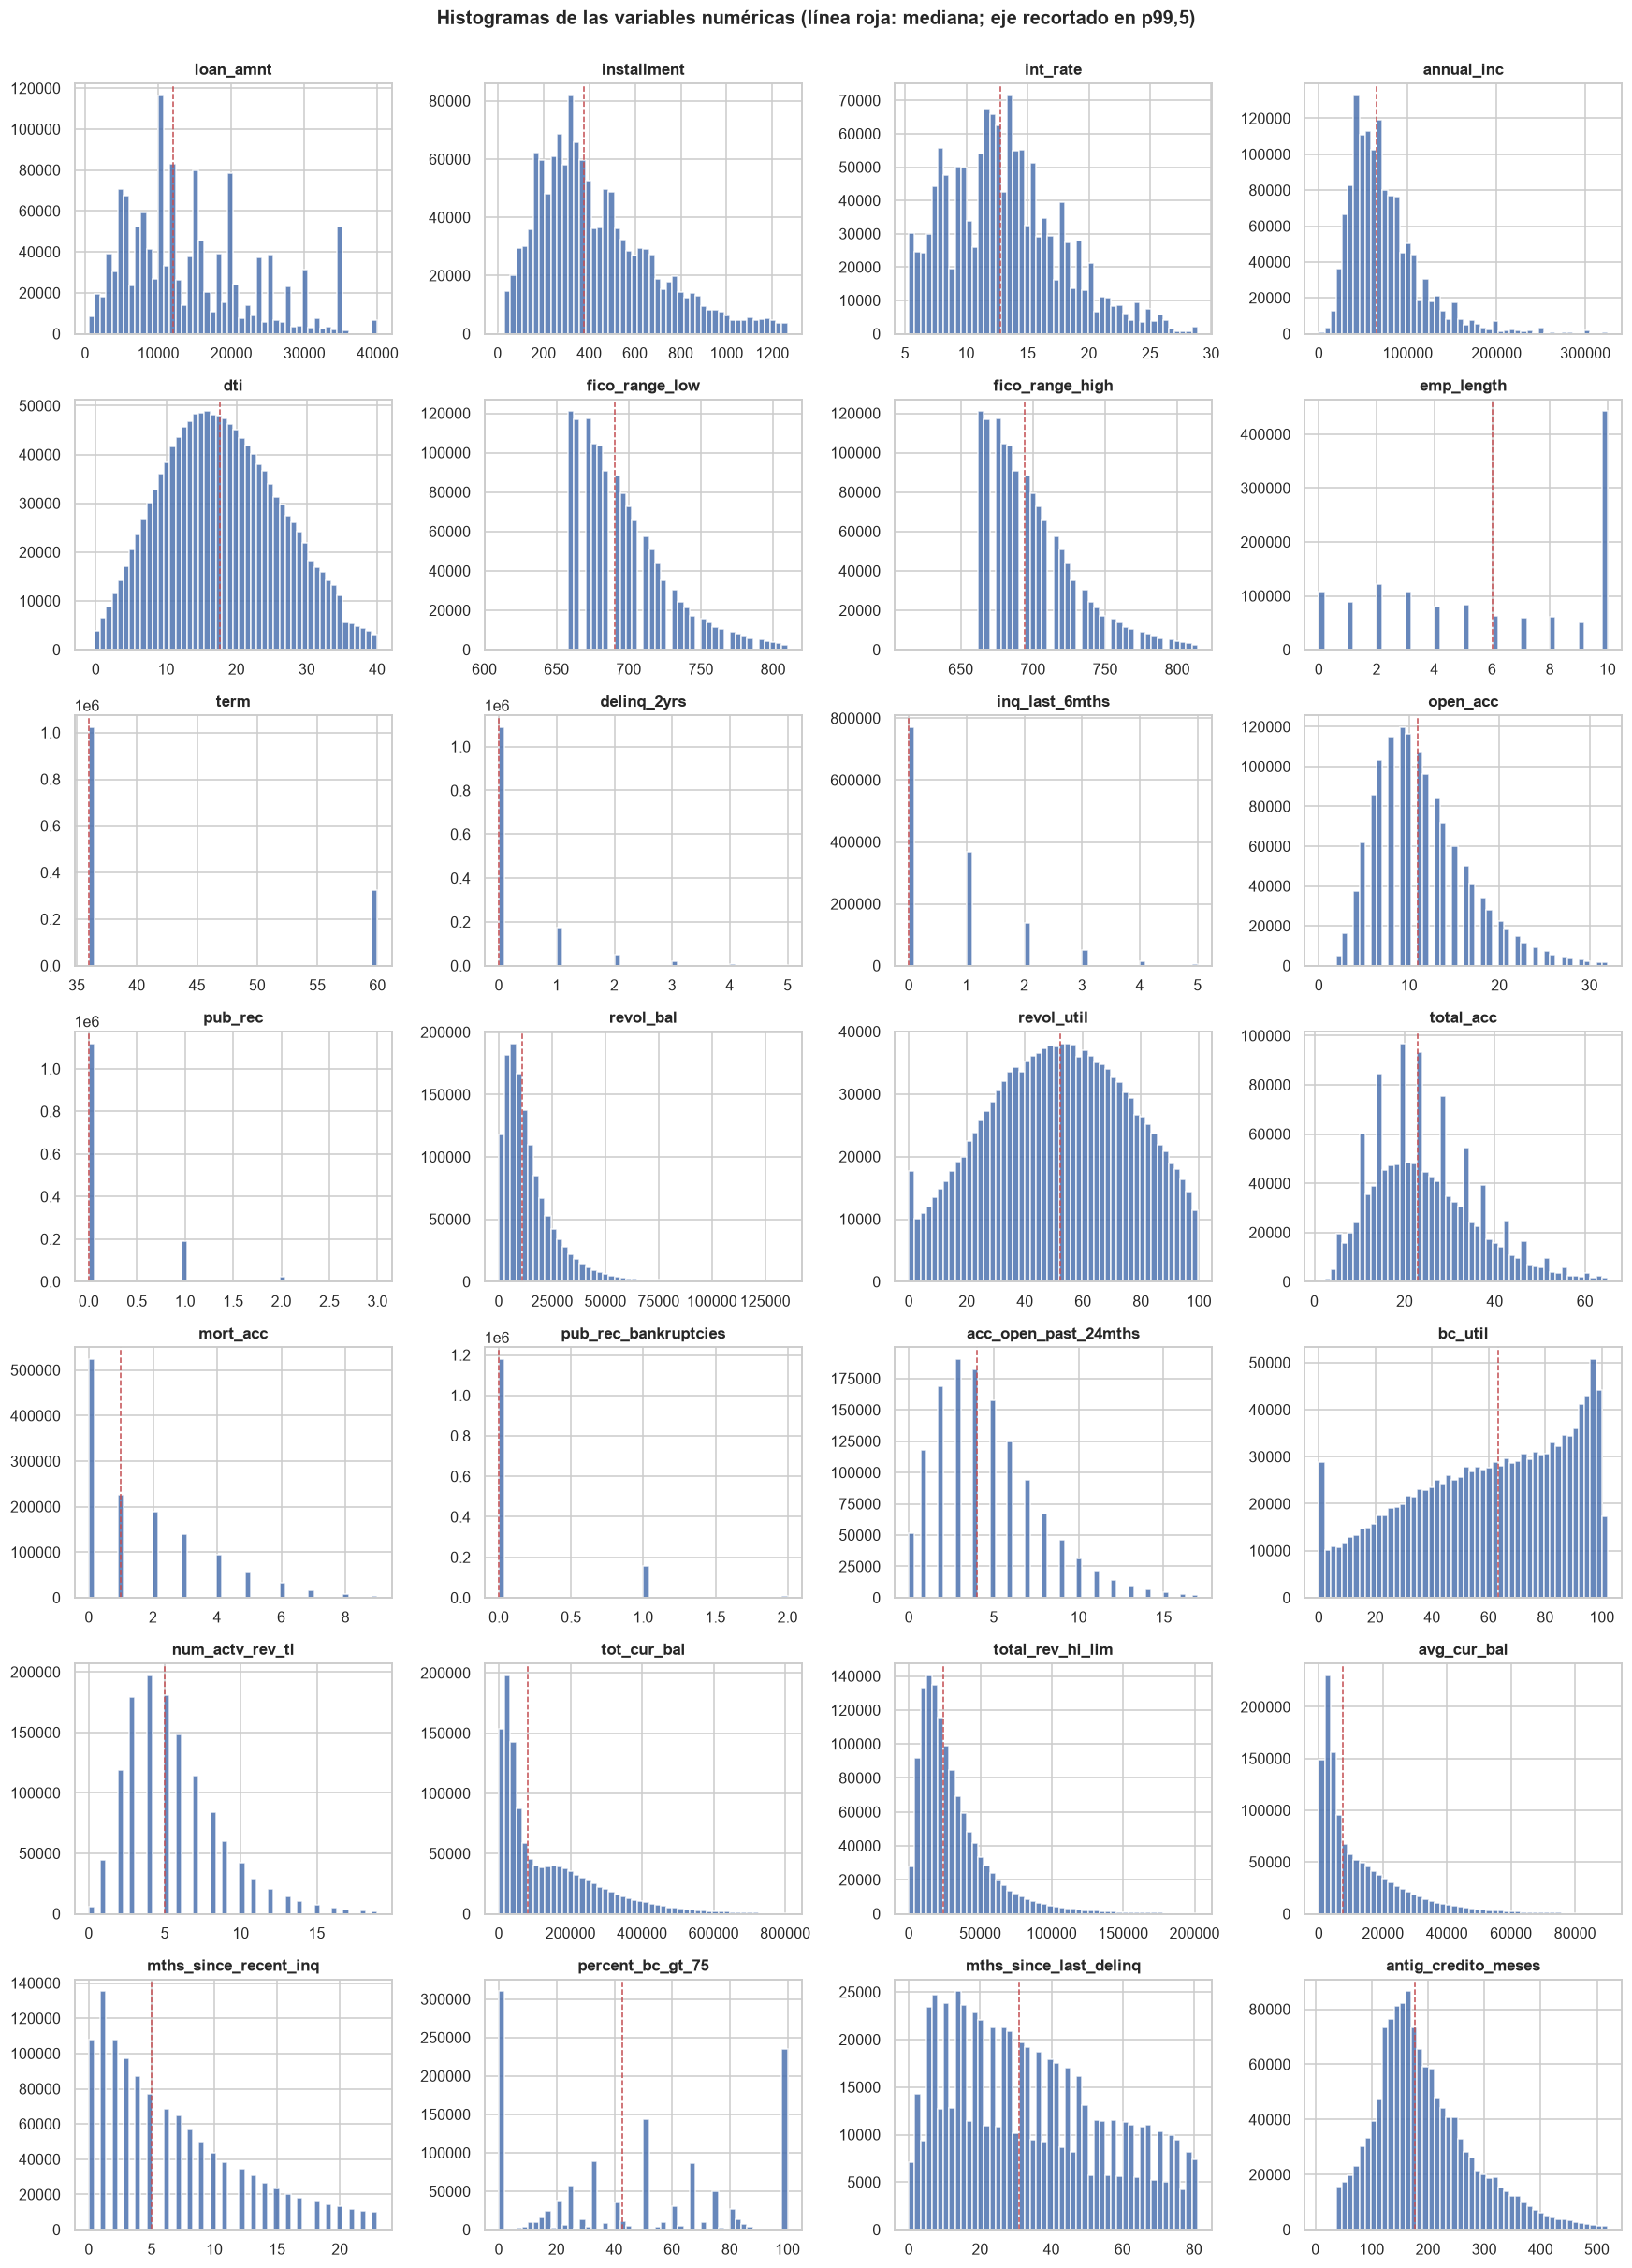

In [3]:
fig, axes = plt.subplots(7, 4, figsize=(16, 22))
for ax, c in zip(axes.ravel(), u.NUM_EDA):
    x = df[c].dropna()
    hi = x.quantile(0.995)
    ax.hist(x[x <= hi], bins=50, color="#4C72B0", alpha=0.85)
    ax.set_title(c)
    ax.set_ylabel("")
    ax.axvline(x.median(), color="#C44E52", ls="--", lw=1)
fig.suptitle("Histogramas de las variables numéricas (línea roja: mediana; eje recortado en p99,5)",
             y=1.0, fontsize=13, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "02_histogramas")
plt.show()

Los histogramas muestran tres formas. **Asimetría a la derecha** en montos, ingresos, saldos y
conteos de cuentas; **distribuciones discretas** en `term` (36 o 60 meses, con 76 % a 36),
`emp_length` (acumulación en 10+ años) y los conteos de moras y consultas; y **forma casi
acampanada** solo en `int_rate` y, en menor medida, en `fico_range_high`, que está acotada por
abajo: solo 489 préstamos tienen un puntaje inferior a 660, porque Lending Club exigía un
mínimo para aprobar.

### 2.1.3 Diagramas de caja

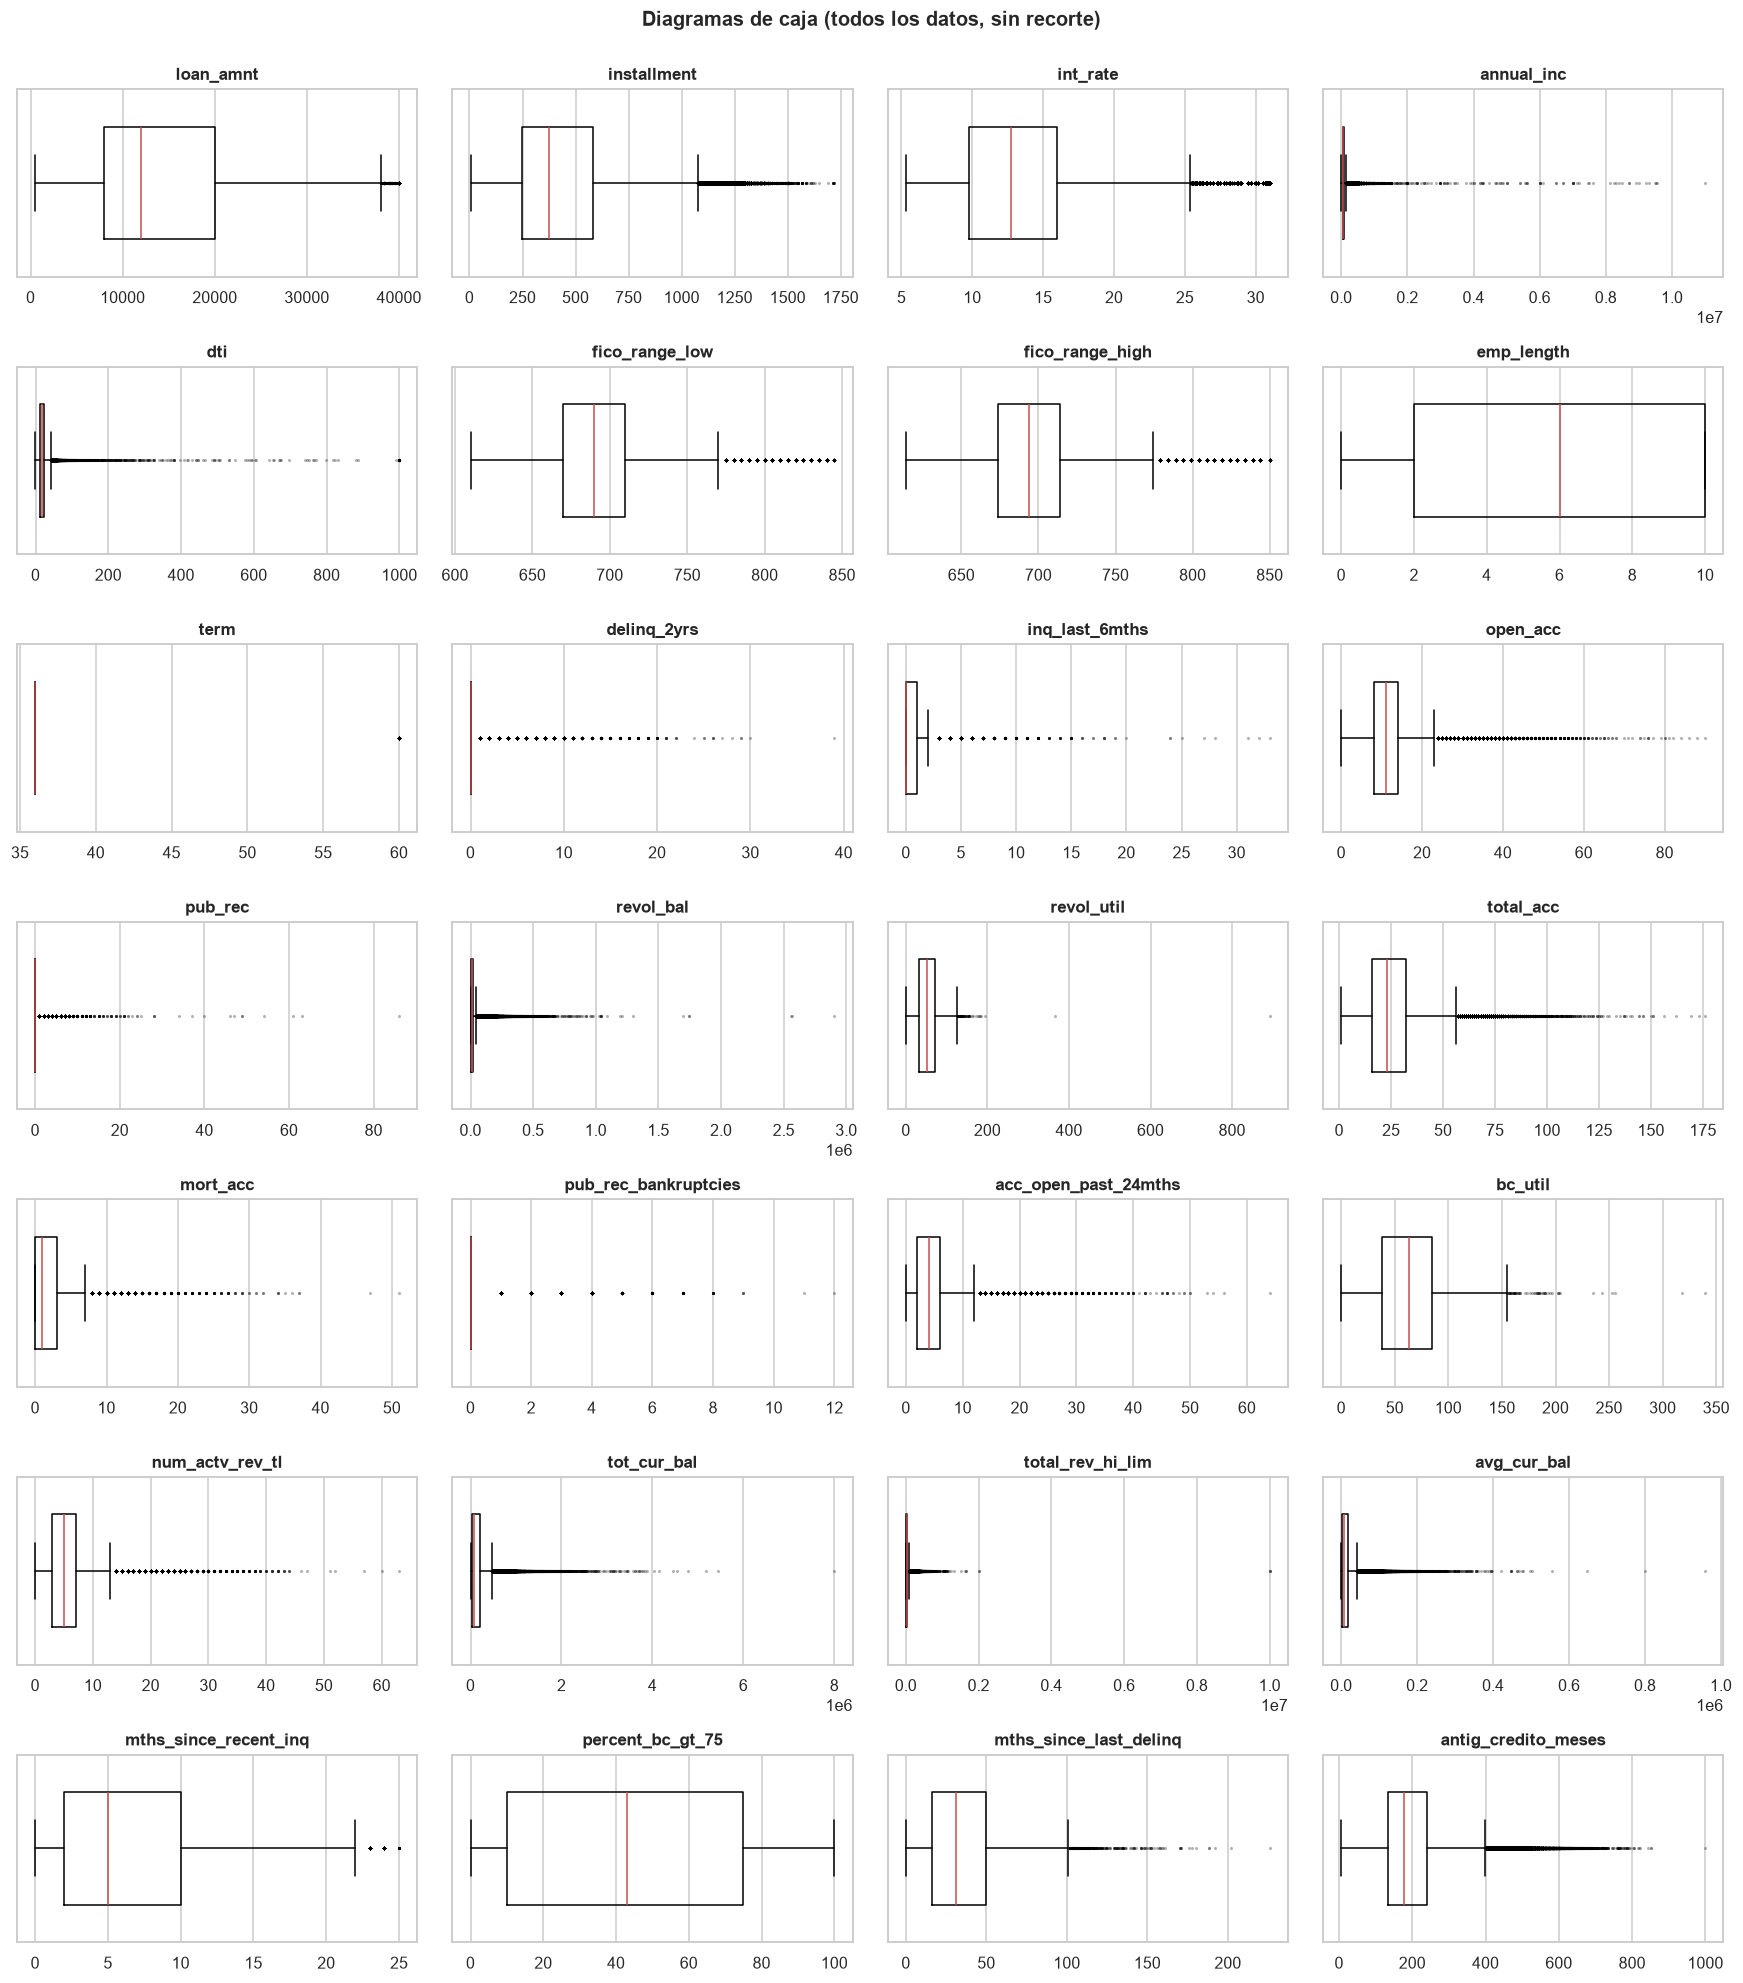

In [4]:
fig, axes = plt.subplots(7, 4, figsize=(16, 18))
for ax, c in zip(axes.ravel(), u.NUM_EDA):
    ax.boxplot(df[c].dropna(), vert=False, widths=0.6, showfliers=True,
               flierprops={"marker": ".", "markersize": 2, "alpha": 0.3},
               medianprops={"color": "#C44E52"})
    ax.set_title(c)
    ax.set_yticks([])
fig.suptitle("Diagramas de caja (todos los datos, sin recorte)", y=1.0, fontsize=13, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "02_boxplots")
plt.show()

Sin recorte, los diagramas de caja de ingresos y saldos quedan comprimidos contra el cero por unos
pocos valores extremos (`annual_inc` de 11 millones, `tot_cur_bal` de 8 millones). Las
variables de tasa, FICO, monto y plazo tienen cajas legibles y bigotes cortos, lo que confirma su
baja asimetría.

### 2.1.4 Normalidad y necesidad de transformaciones

Se reporta la asimetría con todos los datos y la prueba de Shapiro-Wilk sobre una muestra aleatoria
de 5.000 observaciones (semilla 42). Con más de un millón de datos cualquier prueba formal
rechaza la normalidad ante desviaciones mínimas, por lo que la asimetría es el criterio práctico:
$|g_1| > 1$ indica asimetría fuerte. Para las variables no negativas y asimétricas se calcula la
asimetría después de aplicar $\log(1 + x)$.

In [5]:
rng = np.random.default_rng(u.SEMILLA)
filas = []
for c in u.NUM_EDA:
    x = df[c].dropna().to_numpy()
    muestra = rng.choice(x, 5000, replace=False)
    w, p = stats.shapiro(muestra)
    g1 = stats.skew(x)
    g1_log = stats.skew(np.log1p(x)) if x.min() >= 0 else np.nan
    filas.append({"variable": c, "asimetria": g1, "asimetria_log1p": g1_log, "shapiro_W": w,
                  "shapiro_p": p, "normal (p>0,05)": p > 0.05})
normalidad = pd.DataFrame(filas).set_index("variable")
# log1p solo para montos en dólares con asimetría > 2; los conteos se tratan aparte (ver texto)
monetarias = ["annual_inc", "revol_bal", "tot_cur_bal", "total_rev_hi_lim", "avg_cur_bal"]
normalidad["recomendación"] = np.where(normalidad.index.isin(monetarias), "log1p", "escalar")
normalidad.round(3)

,asimetria,asimetria_log1p,shapiro_W,shapiro_p,"normal (p>0,05)",recomendación
variable,,,,,,
loan_amnt,0.783,-0.653,0.938,0.0,False,escalar
installment,1.007,-0.598,0.927,0.0,False,escalar
int_rate,0.713,-0.127,0.968,0.0,False,escalar
annual_inc,46.241,-1.880,0.703,0.0,False,log1p
dti,27.092,NaN,0.451,0.0,False,escalar
fico_range_low,1.284,1.156,0.887,0.0,False,escalar
fico_range_high,1.285,1.157,0.887,0.0,False,escalar
emp_length,-0.216,-0.970,0.851,0.0,False,escalar
term,1.211,1.211,0.531,0.0,False,escalar


Ninguna variable pasa la prueba de Shapiro-Wilk, ni siquiera `int_rate` o `fico_range_high`, cuya
forma es la más cercana a la campana. En los cinco montos en dólares con asimetría mayor que 2 la
transformación $\log(1+x)$ reduce la asimetría de 46,2 a −1,9 (`annual_inc`), de 51,8 a −1,0
(`total_rev_hi_lim`), de 13,7 a −2,7 (`revol_bal`), de 3,9 a −0,4 (`avg_cur_bal`) y de 2,9 a
−0,7 (`tot_cur_bal`); se adopta para ellas en el preprocesamiento. La asimetría negativa que
queda proviene de los ceros (361 ingresos y 6.687 saldos rotativos iguales a 0), que el logaritmo
separa del resto. En los conteos de moras, consultas y registros públicos el logaritmo también
reduce la asimetría, pero el problema es la masa en cero y no la escala; se dejan como están. Los árboles y bosques son invariantes a transformaciones monótonas, así que el
logaritmo solo afecta a la regresión logística, al SVM lineal y a Naive Bayes gaussiano.

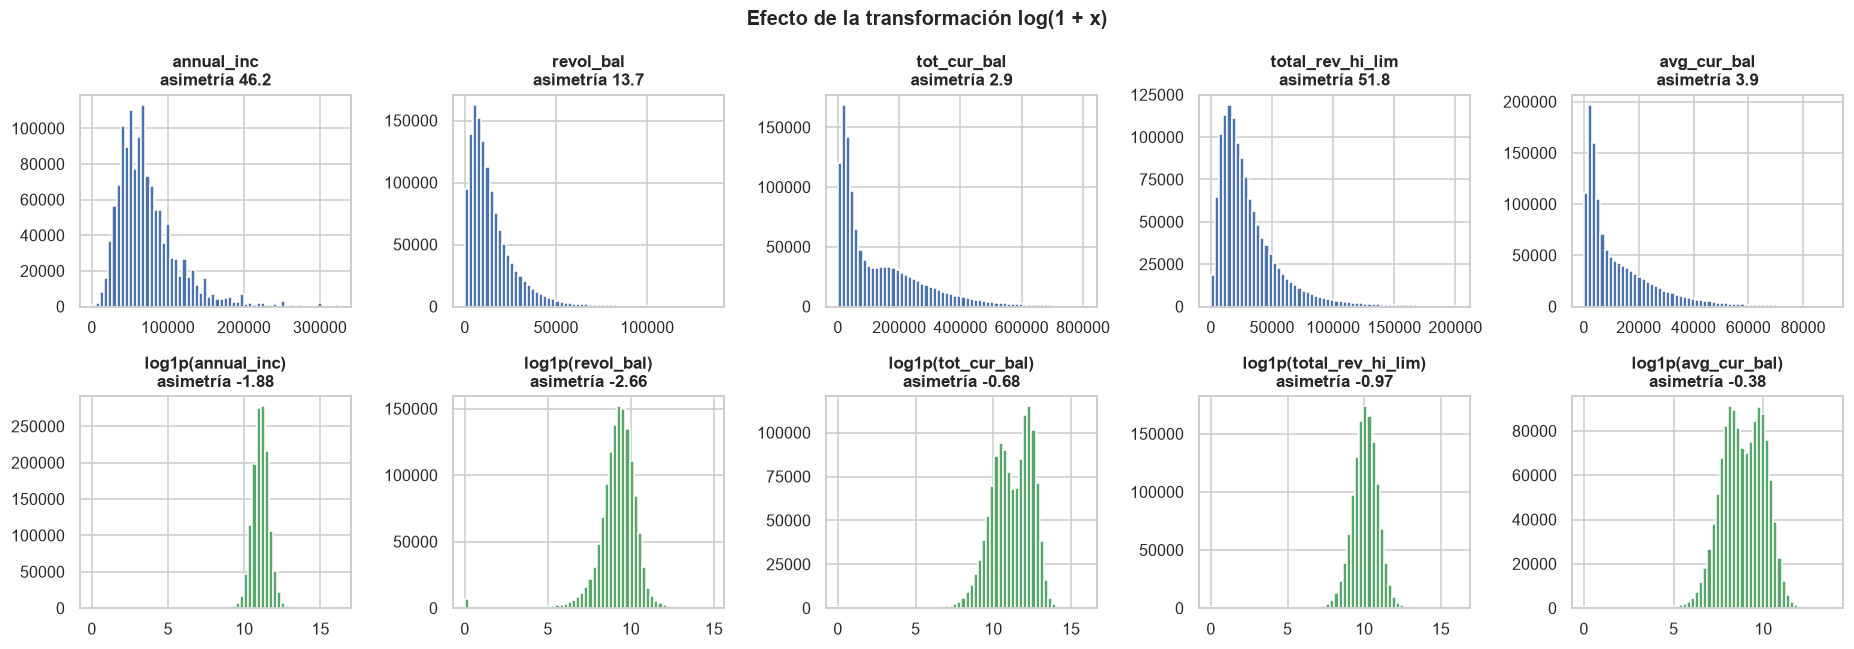

In [6]:
transformar = ["annual_inc", "revol_bal", "tot_cur_bal", "total_rev_hi_lim", "avg_cur_bal"]
fig, axes = plt.subplots(2, 5, figsize=(17, 6))
for j, c in enumerate(transformar):
    x = df[c].dropna()
    axes[0, j].hist(x[x <= x.quantile(0.995)], bins=60, color="#4C72B0")
    axes[0, j].set_title(f"{c}\nasimetría {stats.skew(x):.1f}")
    axes[1, j].hist(np.log1p(x), bins=60, color="#55A868")
    axes[1, j].set_title(f"log1p({c})\nasimetría {stats.skew(np.log1p(x)):.2f}")
fig.suptitle("Efecto de la transformación log(1 + x)", fontsize=13, weight="bold")
fig.tight_layout()
u.guardar_fig(fig, "02_log1p")
plt.show()

### 2.1.5 Valores faltantes en las variables numéricas

Se fija un umbral de 30 %: por encima de él una imputación por mediana reemplazaría demasiados
valores con un mismo número y distorsionaría la distribución.

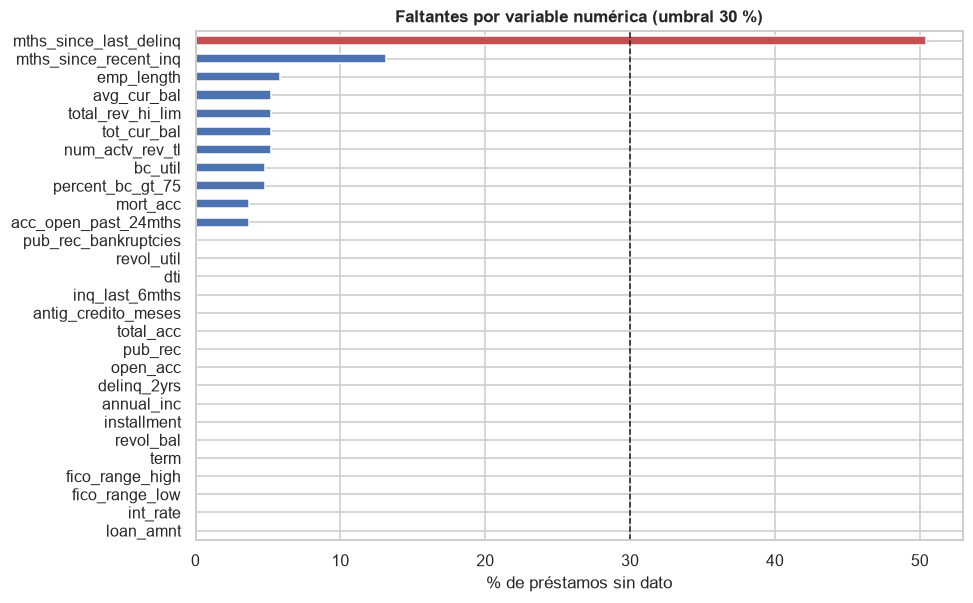

,mths_since_last_delinq,mths_since_recent_inq,emp_length,avg_cur_bal,total_rev_hi_lim,tot_cur_bal,num_actv_rev_tl,bc_util,percent_bc_gt_75,mort_acc,acc_open_past_24mths,pub_rec_bankruptcies,revol_util,dti,inq_last_6mths,antig_credito_meses,total_acc,pub_rec,open_acc,delinq_2yrs,annual_inc
% faltantes,50.44,13.12,5.83,5.21,5.21,5.21,5.21,4.8,4.77,3.71,3.71,0.1,0.07,0.03,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
falt_num = (100 * df[u.NUM_EDA].isna().mean()).sort_values(ascending=False).rename("% faltantes")
fig, ax = plt.subplots(figsize=(9, 6))
falt_num.plot.barh(ax=ax, color=np.where(falt_num > 30, "#C44E52", "#4C72B0"))
ax.axvline(30, color="k", ls="--", lw=1)
ax.invert_yaxis()
ax.set_xlabel("% de préstamos sin dato")
ax.set_title("Faltantes por variable numérica (umbral 30 %)")
u.guardar_fig(fig, "02_faltantes_numericas")
plt.show()
falt_num[falt_num > 0].round(2).to_frame().T

Solo `mths_since_last_delinq` (meses desde la última mora) supera el umbral, con 50,4 % de
faltantes. Su ausencia no es un error: significa que el prestatario **nunca** ha estado en mora.
Imputarla con la mediana borraría esa información; se reemplaza por un indicador binario
`hist_morosidad` (1 si hay registro de mora). Las demás variables tienen menos de 13 % de
faltantes y se imputan con la mediana del conjunto de entrenamiento. Las variables del buró con
cerca de 5 % de faltantes (`tot_cur_bal`, `avg_cur_bal`, `bc_util`...) comparten el mismo patrón,
que el capítulo 4 relaciona con el año de emisión.

## 2.2 Variables categóricas

### 2.2.1 Frecuencias absolutas y relativas

In [8]:
for c in u.CAT_EDA:
    f = df[c].value_counts(dropna=False)
    t = pd.DataFrame({"n": f, "%": (100 * f / len(df)).round(2)})
    t["rara (<1 %)"] = t["%"] < 1
    print(f"\n=== {c}: {df[c].nunique()} categorías, {100 * df[c].isna().mean():.2f} % faltantes ===")
    print(t.to_string() if len(t) <= 20 else t.head(15).to_string() + f"\n... ({len(t) - 15} más)")


=== grade: 7 categorías, 0.00 % faltantes ===
            n      %  rara (<1 %)
grade                            
B      393095  29.16        False
C      382315  28.36        False
A      235188  17.45        False
D      201644  14.96        False
E       94186   6.99        False
F       32305   2.40        False
G        9326   0.69         True

=== purpose: 14 categorías, 0.00 % faltantes ===
                         n      %  rara (<1 %)
purpose                                       
debt_consolidation  781421  57.97        False
credit_card         295619  21.93        False
home_improvement     87718   6.51        False
other                78299   5.81        False
major_purchase       29548   2.19        False
medical              15612   1.16        False
small_business       15577   1.16        False
car                  14649   1.09        False
moving                9526   0.71         True
vacation              9084   0.67         True
house                 7297   0.54


=== initial_list_status: 2 categorías, 0.00 % faltantes ===
                          n      %  rara (<1 %)
initial_list_status                            
w                    784010  58.16        False
f                    564049  41.84        False


### 2.2.2 Gráficos de barras

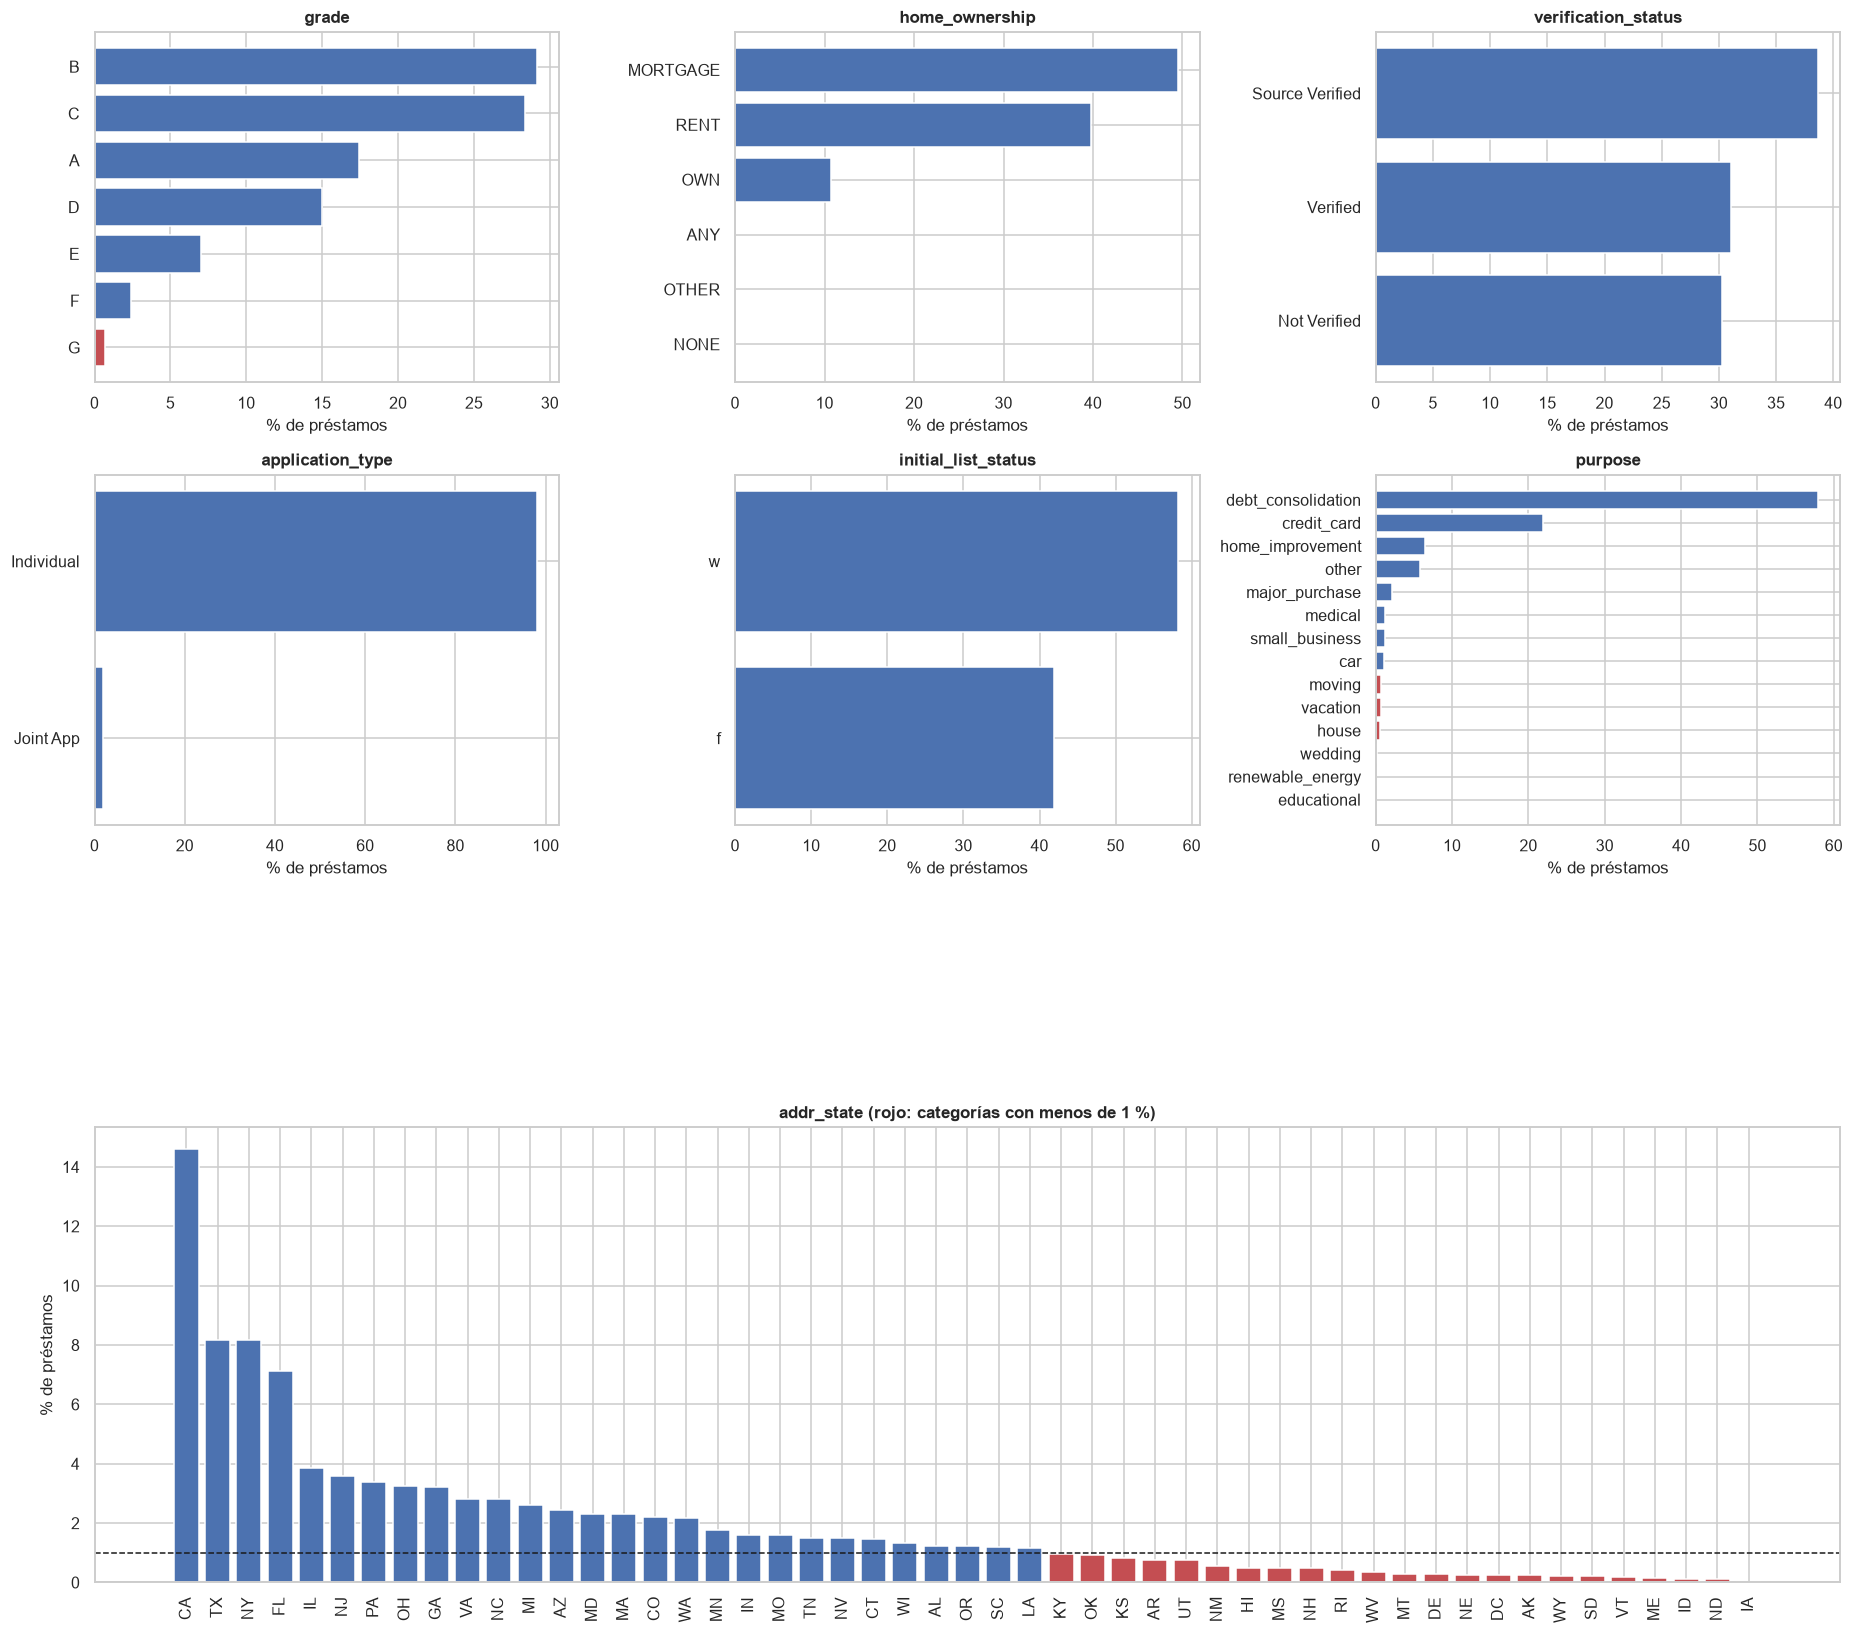

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(17, 15), gridspec_kw={"height_ratios": [1, 1, 1.9]})
orden = ["grade", "home_ownership", "verification_status", "application_type",
         "initial_list_status", "purpose"]
for ax, c in zip(axes.ravel()[:6], orden):
    f = 100 * df[c].value_counts(normalize=True).sort_values()
    ax.barh(f.index.astype(str), f.values, color=np.where(f.values < 1, "#C44E52", "#4C72B0"))
    ax.set_title(c)
    ax.set_xlabel("% de préstamos")
for ax in axes[2, :]:
    ax.remove()
ax = fig.add_subplot(3, 1, 3)
f = 100 * df["addr_state"].value_counts(normalize=True)
ax.bar(f.index, f.values, color=np.where(f.values < 1, "#C44E52", "#4C72B0"))
ax.axhline(1, color="k", ls="--", lw=1)
ax.set_title("addr_state (rojo: categorías con menos de 1 %)")
ax.set_ylabel("% de préstamos")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()
u.guardar_fig(fig, "02_categoricas")
plt.show()

### 2.2.3 Categorías raras y redundancias

* **`home_ownership`**: `ANY`, `NONE` y `OTHER` suman menos de 0,1 %. Las tres significan "sin
  vivienda propia ni hipoteca ni arriendo declarado" y se unifican en `OTHER`.
* **`purpose`**: 14 propósitos, de los cuales `debt_consolidation` y `credit_card` concentran
  cerca de 80 %. Los propósitos con menos de 1 % (`wedding`, `renewable_energy`, `educational`,
  `vacation`, `house`, `moving`...) se agrupan en `other`, categoría que ya existe con el mismo
  significado.
* **`addr_state`**: 23 de los 51 estados tienen menos de 1 % de los préstamos cada uno y en
  conjunto suman 9,4 %. Se agrupan en `OTROS`: su tasa de default difiere poco de la media
  (capítulo 3) y 23 columnas binarias más añadirían costo sin ganancia apreciable.
* **`verification_status`**: `Source Verified` (se verificó la fuente del ingreso) y `Verified`
  (se verificó el ingreso) son niveles distintos de verificación; no se unifican.
* **`application_type`**: `Joint App` tiene menos de 2 %, pero es una categoría binaria con
  significado propio y no puede agruparse con otra.
* **`grade`**: es la calificación de riesgo que asigna Lending Club y determina la tasa de
  interés; su redundancia con `int_rate` se mide en el capítulo 3.

Ninguna de las variables categóricas seleccionadas tiene valores faltantes, así que no hace falta
una categoría "Desconocido"; aun así, el codificador se configura para aceptar categorías nuevas en
el conjunto de prueba.

## 2.3 Variable objetivo `default`

,clase,n,%
0,Fully Paid (0),1078739,80.02
1,Charged Off (1),269320,19.98


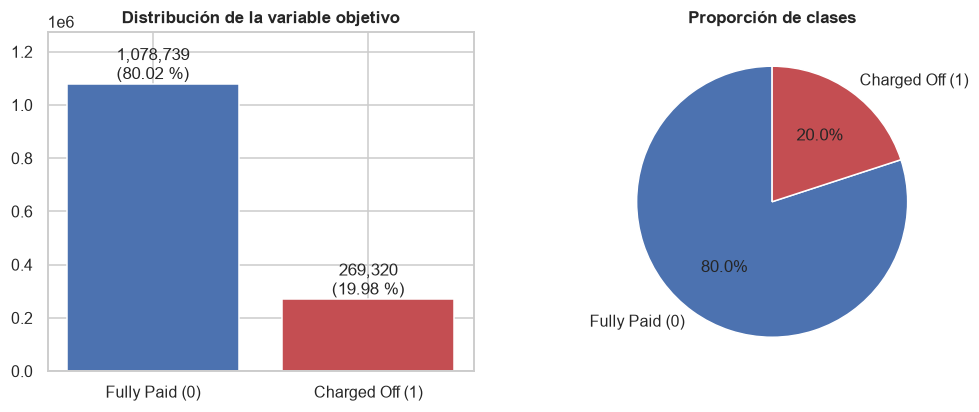

Razón de desbalance: 4.01 préstamos pagados por cada default


In [10]:
dist = df["default"].value_counts().sort_index()
tabla = pd.DataFrame({"clase": [u.ETIQUETAS[i] for i in dist.index], "n": dist.values,
                      "%": (100 * dist / dist.sum()).round(2).values})
display(tabla)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.bar(tabla["clase"], tabla["n"], color=[u.PALETA[0], u.PALETA[1]])
for i, (n, p) in enumerate(zip(tabla["n"], tabla["%"])):
    a1.text(i, n, f"{n:,}\n({p} %)", ha="center", va="bottom")
a1.set_ylim(0, tabla["n"].max() * 1.18)
a1.set_title("Distribución de la variable objetivo")
a2.pie(tabla["n"], labels=tabla["clase"], autopct="%1.1f%%", colors=[u.PALETA[0], u.PALETA[1]],
       startangle=90, wedgeprops={"edgecolor": "white"})
a2.set_title("Proporción de clases")
u.guardar_fig(fig, "02_objetivo")
plt.show()
print(f"Razón de desbalance: {dist[0] / dist[1]:.2f} préstamos pagados por cada default")

Uno de cada cinco préstamos cerrados terminó en default (razón 4:1). El desbalance es moderado,
no extremo, pero tiene tres consecuencias para el modelado:

1. La **exactitud** es engañosa: un clasificador que siempre predice "pagado" acierta en 80 % de
   los casos sin detectar ningún default. Por eso el criterio de selección es el AUC ROC, que no
   depende del umbral ni de la proporción de clases, y se reportan también precisión, recall, F1
   y AUC-PR para la clase minoritaria.
2. La partición entrenamiento/prueba y los pliegues de validación cruzada se **estratifican** por
   clase para conservar el 20 % de default en todos ellos.
3. El umbral de 0,5 sobre la probabilidad es inadecuado cuando la clase positiva es 20 %: casi
   ningún préstamo alcanza esa probabilidad y el recall sería bajo. El umbral de decisión se ajusta
   con los datos de entrenamiento (capítulo 8). No se aplica sobremuestreo (SMOTE) ni submuestreo,
   porque el enunciado exige usar el conjunto completo y el AUC no depende del balance de clases.